# Trabalho Final PDI: Detecção e Contagem de Células


In [1]:
import cv2
import numpy as np
import matplotlib.pyplot as plt
import glob
import os
# Configuração para mostrar as imagens em tamanho adequado no Jupyter
plt.rcParams['figure.figsize'] = (10, 8)

## 1. Carregamento da Imagem
Nesta etapa, carregamos a imagem em tons de cinza. Utilizamos a primeira imagem fornecida na base de dados para demonstrar o passo a passo.

Processando imagem de exemplo: imagens\AS_09125_050118150001_A03f00d0.tif


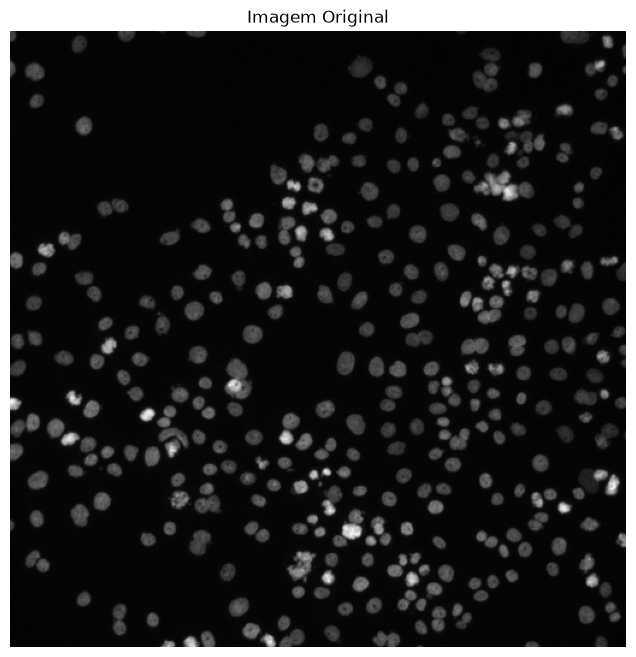

In [4]:
# Busca automaticamente todos os arquivos .tif na pasta 'imagens'
arquivos_tif = sorted(glob.glob(os.path.join('imagens', '*.tif')))

# Pega o primeiro arquivo da lista para o passo a passo
image_path = arquivos_tif[0]
print(f"Processando imagem de exemplo: {image_path}")

img = cv2.imread(image_path, cv2.IMREAD_GRAYSCALE)

plt.imshow(img, cmap='gray')
plt.title('Imagem Original')
plt.axis('off')
plt.show()

## 2. Pré-processamento (Suavização)
Para mitigar o ruído inerente à captura microscópica, aplicamos um **Filtro Gaussiano**. Ele preserva o formato geral das células enquanto elimina variações de alta frequência no fundo escuro.

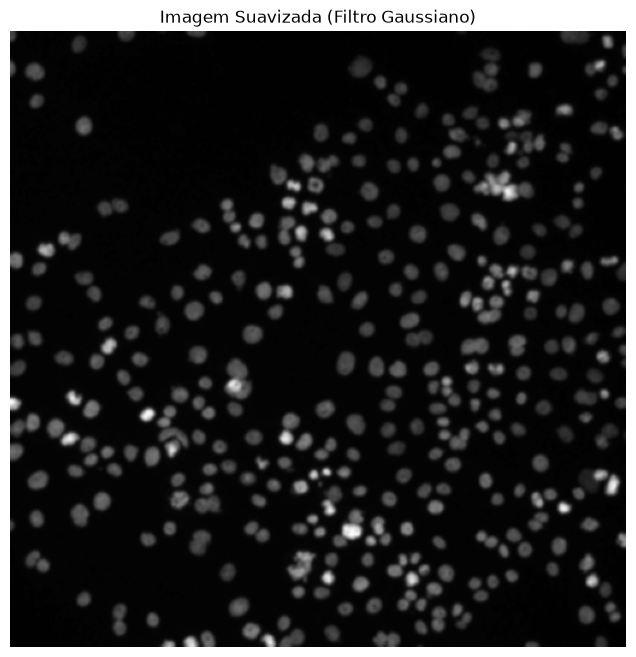

In [5]:
img_blur = cv2.GaussianBlur(img, (5, 5), 0)

plt.imshow(img_blur, cmap='gray')
plt.title('Imagem Suavizada (Filtro Gaussiano)')
plt.axis('off')
plt.show()

## 3. Binarização (Limiarização de Otsu)
O método de Otsu é uma das técnicas mais elegantes de PDI clássico. Ele percorre o histograma da imagem e encontra automaticamente o melhor ponto de corte (limiar) que separa os pixels do fundo (classe 1) dos pixels das células (classe 2), minimizando a variância dentro de cada classe.

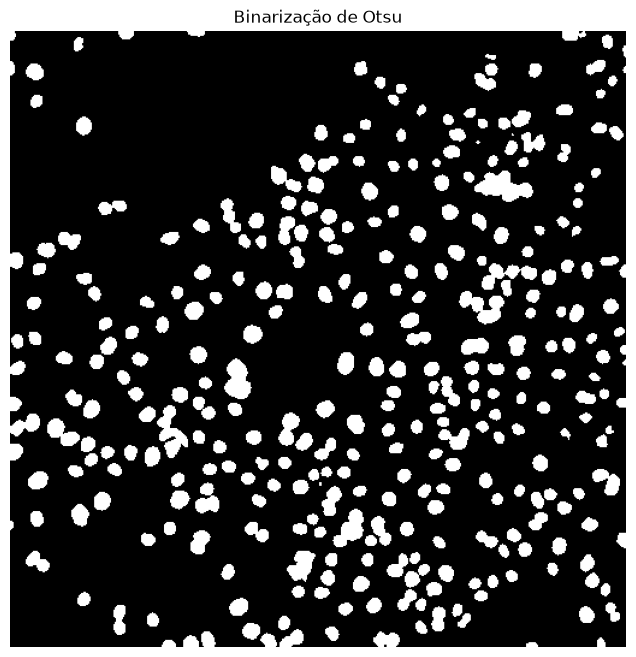

In [6]:
_, thresh = cv2.threshold(img_blur, 0, 255, cv2.THRESH_BINARY + cv2.THRESH_OTSU)

plt.imshow(thresh, cmap='gray')
plt.title('Binarização de Otsu')
plt.axis('off')
plt.show()

## 4. Operações Morfológicas
Para limpar a imagem binarizada:
- Aplicamos uma **Abertura** (Erosão $\rightarrow$ Dilatação) para apagar pequenos pontos de ruído.
- Aplicamos uma **Dilatação** adicional apenas para definir uma área que temos certeza absoluta de ser o fundo.

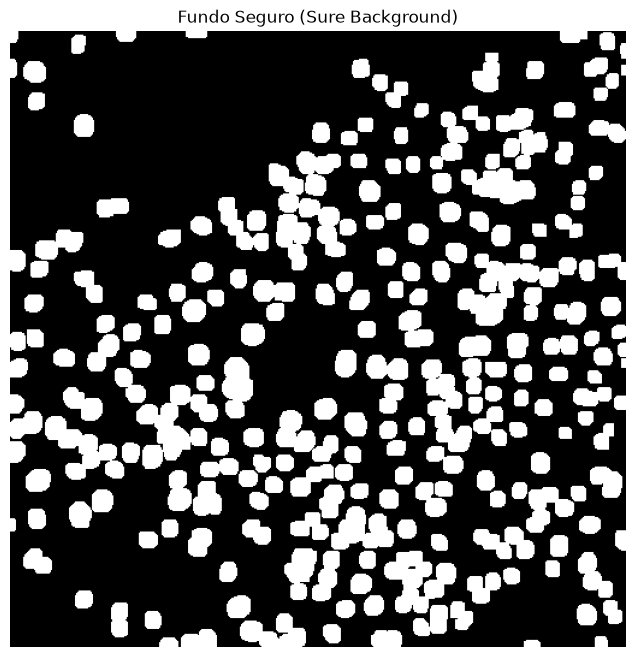

In [7]:
kernel = np.ones((3,3), np.uint8)

# Abertura para remover ruídos externos
opening = cv2.morphologyEx(thresh, cv2.MORPH_OPEN, kernel, iterations=1)

# Dilatação para extrair a área de fundo seguro (background)
sure_bg = cv2.dilate(opening, kernel, iterations=2)

plt.imshow(sure_bg, cmap='gray')
plt.title('Fundo Seguro (Sure Background)')
plt.axis('off')
plt.show()

## 5. Transformada de Distância e Watershed
Este é o coração da solução para células sobrepostas. Se apenas contarmos contornos, agrupamentos de células serão contados como 1. 
- A **Transformada de Distância** calcula a distância de cada pixel branco até o pixel preto mais próximo, gerando picos no centro de cada célula.
- O algoritmo **Watershed** ("Divisor de Águas") inunda esses picos como bacias hidrográficas e constrói barreiras virtuais onde a água de duas células se encontra, separando-as.

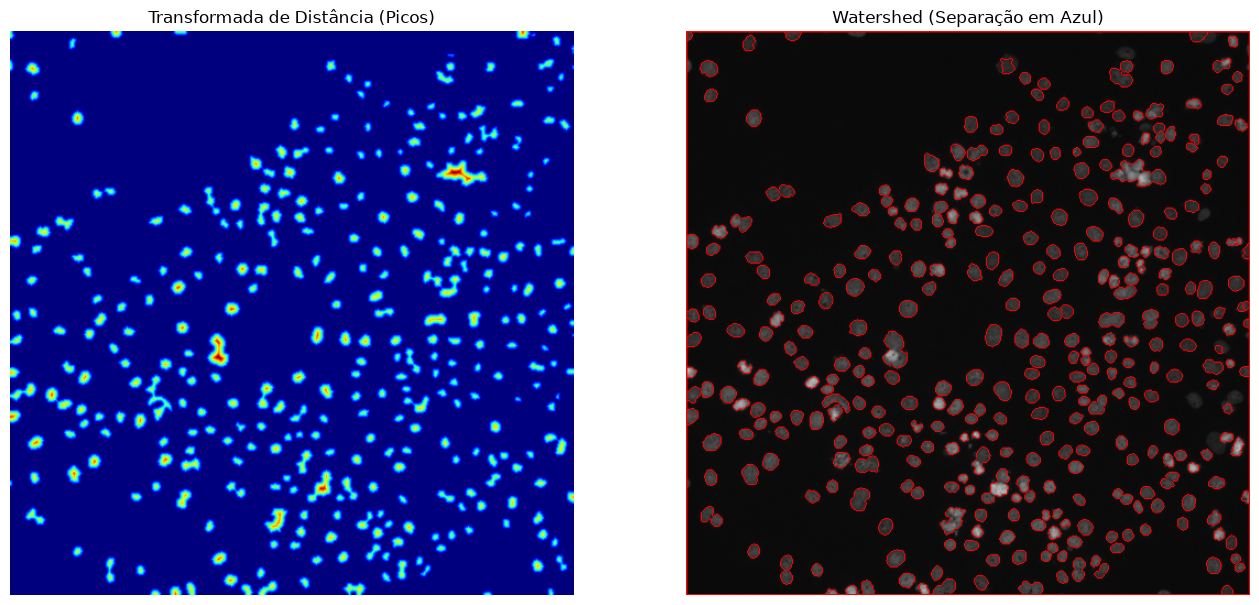

In [8]:
# Transformada de distância
dist_transform = cv2.distanceTransform(opening, cv2.DIST_L2, 5)

# Limiarização agressiva para encontrar o centro seguro das células
_, sure_fg = cv2.threshold(dist_transform, 0.4 * dist_transform.max(), 255, 0)
sure_fg = np.uint8(sure_fg)

# Região desconhecida (bordas de sobreposição)
unknown = cv2.subtract(sure_bg, sure_fg)

# Criação de marcadores para o Watershed
_, markers = cv2.connectedComponents(sure_fg)
markers = markers + 1
markers[unknown == 255] = 0

# O Watershed requer 3 canais
img_color = cv2.cvtColor(img, cv2.COLOR_GRAY2BGR)
markers = cv2.watershed(img_color, markers)
img_color[markers == -1] = [255, 0, 0] # Pintando bordas de separação em azul

fig, ax = plt.subplots(1, 2, figsize=(16, 8))
ax[0].imshow(dist_transform, cmap='jet')
ax[0].set_title('Transformada de Distância (Picos)')
ax[0].axis('off')

ax[1].imshow(img_color)
ax[1].set_title('Watershed (Separação em Azul)')
ax[1].axis('off')
plt.show()

## 6. Contagem e Detecção Final
Iteramos pelos marcadores únicos gerados pelo Watershed, isolando cada célula. Filtramos os resultados calculando a área para descartar eventuais artefatos diminutos, traçamos o contorno e exibimos a contagem.

-> Total de células contadas na imagem: 342


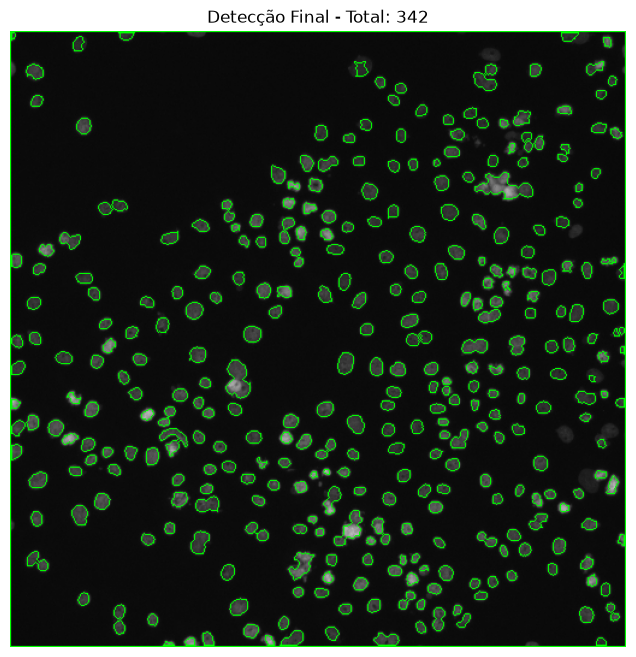

In [9]:
img_final = cv2.cvtColor(img, cv2.COLOR_GRAY2BGR)
count = 0

# Marcadores >= 2 são células detectadas (0=desconhecido, 1=fundo)
for marker in np.unique(markers):
    if marker == 0 or marker == 1:
        continue
    
    # Extração de máscara individual para o contorno atual
    mask = np.zeros_like(img, dtype="uint8")
    mask[markers == marker] = 255
    
    contours, _ = cv2.findContours(mask.copy(), cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE)
    if not contours:
        continue
        
    c = max(contours, key=cv2.contourArea)
    
    # Filtro de área mínima (10 pixels)
    if cv2.contourArea(c) > 10:
        cv2.drawContours(img_final, [c], -1, (0, 255, 0), 1)
        count += 1

print(f"-> Total de células contadas na imagem: {count}")

plt.imshow(cv2.cvtColor(img_final, cv2.COLOR_BGR2RGB))
plt.title(f'Detecção Final - Total: {count}')
plt.axis('off')
plt.show()

## 7. Processamento em Lote (Dataset Completo)
Uma vez validado o pipeline, aplicamos as mesmas regras de transformação nas demais imagens do repositório.

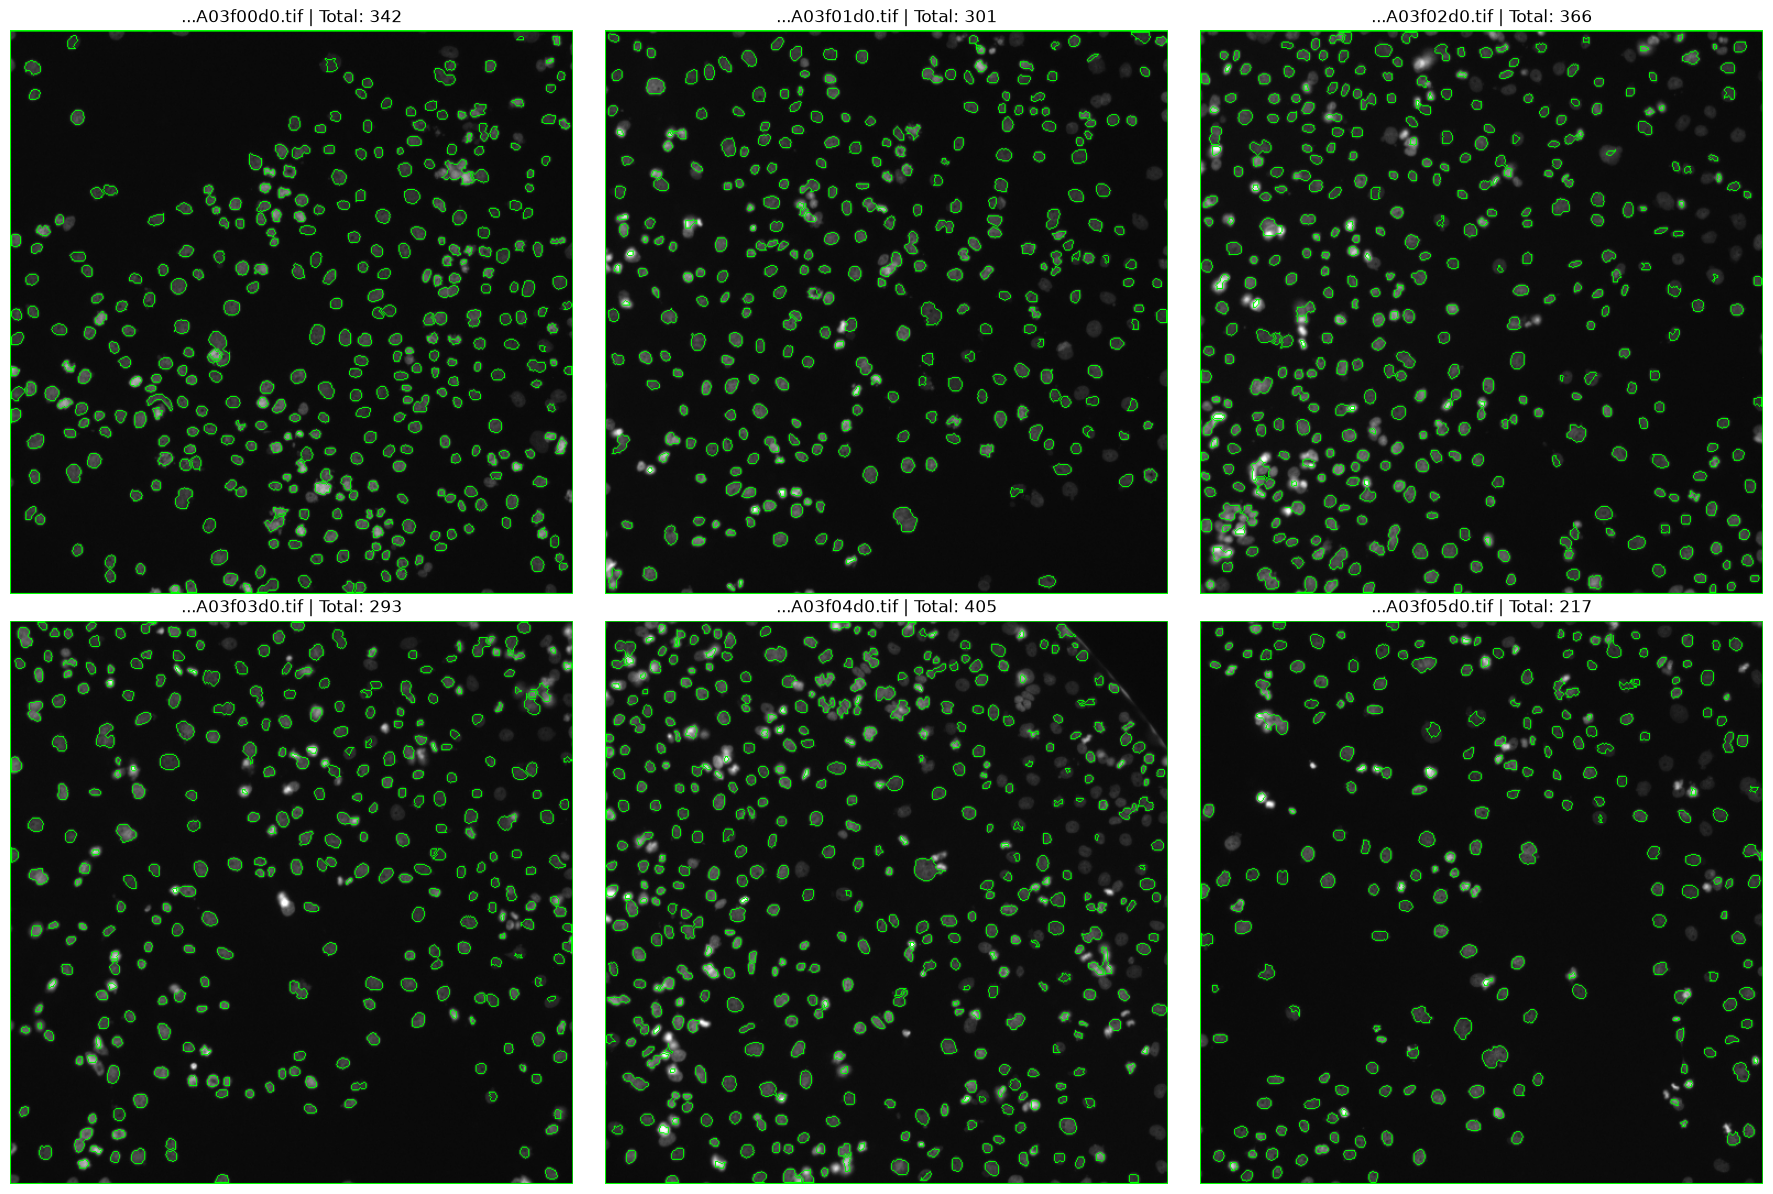

Processamento concluído! As imagens foram salvas na pasta 'resultados'.


In [12]:
from scipy import ndimage as ndi
from skimage.feature import peak_local_max

def contar_celulas_pipeline(image_path, min_distance=7):
    img = cv2.imread(image_path, cv2.IMREAD_GRAYSCALE)
    if img is None: return 0, None
    
    # Pré-processamento e Limiarização
    img_blur = cv2.GaussianBlur(img, (5, 5), 0)
    _, thresh = cv2.threshold(img_blur, 0, 255, cv2.THRESH_BINARY + cv2.THRESH_OTSU)
    
    # Morfologia
    kernel = np.ones((3,3), np.uint8)
    opening = cv2.morphologyEx(thresh, cv2.MORPH_OPEN, kernel, iterations=1)
    sure_bg = cv2.dilate(opening, kernel, iterations=2)
    
    # Transformada de distância
    dist_transform = cv2.distanceTransform(opening, cv2.DIST_L2, 5)
    
    # --- NOVO: detecção de máximos locais em vez de threshold único ---
    coords = peak_local_max(dist_transform, min_distance=min_distance, labels=opening)
    mask_peaks = np.zeros(dist_transform.shape, dtype=bool)
    mask_peaks[tuple(coords.T)] = True
    markers, _ = ndi.label(mask_peaks)
    
    sure_fg = np.uint8(mask_peaks) * 255
    unknown = cv2.subtract(sure_bg, sure_fg)
    
    markers = markers + 1
    markers[unknown == 255] = 0
    # --- fim da alteração ---
    
    img_color = cv2.cvtColor(img, cv2.COLOR_GRAY2BGR)
    markers = cv2.watershed(img_color, markers)
    
    # Contagem
    img_final = cv2.cvtColor(img, cv2.COLOR_GRAY2BGR)
    count = 0
    
    for marker in np.unique(markers):
        if marker == 0 or marker == 1: continue
        mask = np.zeros_like(img, dtype="uint8")
        mask[markers == marker] = 255
        contours, _ = cv2.findContours(mask.copy(), cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE)
        if contours:
            c = max(contours, key=cv2.contourArea)
            if cv2.contourArea(c) > 10:
                cv2.drawContours(img_final, [c], -1, (0, 255, 0), 1)
                count += 1
                
    return count, img_final

# --- resto igual, só ajustei o grid pra ser dinâmico (evita erro se o nº de arquivos mudar) ---
os.makedirs('resultados', exist_ok=True)
arquivos = sorted(glob.glob(os.path.join('imagens', '*.tif')))

cols = 3
rows = (len(arquivos) + cols - 1) // cols
fig, axes = plt.subplots(rows, cols, figsize=(6*cols, 6*rows))
axes = axes.flatten()

for idx, arquivo in enumerate(arquivos):
    total, img_res = contar_celulas_pipeline(arquivo)
    
    if img_res is not None:
        nome_arquivo = os.path.basename(arquivo)
        caminho_salvar = os.path.join('resultados', f'resultado_{nome_arquivo}')
        cv2.imwrite(caminho_salvar, img_res)
        
        axes[idx].imshow(cv2.cvtColor(img_res, cv2.COLOR_BGR2RGB))
        axes[idx].set_title(f'...{nome_arquivo[-12:]} | Total: {total}')
    else:
        axes[idx].set_title(f'Erro ao ler: {arquivo}')
    axes[idx].axis('off')

# apaga eixos vazios se o nº de imagens não fechar a grade
for ax in axes[len(arquivos):]:
    ax.axis('off')

plt.tight_layout()
plt.show()
print("Processamento concluído! As imagens foram salvas na pasta 'resultados'.")

In [13]:
# Contagens manuais de referência (extraídas da tabela fornecida)
contagens_manuais = {
    'AS_09125_050118150001_A03f00d0.tif': (350, 362),
    'AS_09125_050118150001_A03f01d0.tif': (336, 342),
    'AS_09125_050118150001_A03f02d0.tif': (396, 447),
    'AS_09125_050118150001_A03f03d0.tif': (320, 341),
    'AS_09125_050118150001_A03f04d0.tif': (398, 533),
    'AS_09125_050118150001_A03f05d0.tif': (241, 257),
}

print(f"{'Imagem':<45}{'Automático':>12}{'Manual (méd)':>15}{'Erro %':>10}")
for arquivo in arquivos:
    nome = os.path.basename(arquivo)
    total, _ = contar_celulas_pipeline(arquivo)
    if nome in contagens_manuais:
        m1, m2 = contagens_manuais[nome]
        media_manual = (m1 + m2) / 2
        erro = 100 * (total - media_manual) / media_manual
        print(f"{nome:<45}{total:>12}{media_manual:>15.1f}{erro:>+9.1f}%")

Imagem                                         Automático   Manual (méd)    Erro %
AS_09125_050118150001_A03f00d0.tif                    342          356.0     -3.9%
AS_09125_050118150001_A03f01d0.tif                    301          339.0    -11.2%
AS_09125_050118150001_A03f02d0.tif                    366          421.5    -13.2%
AS_09125_050118150001_A03f03d0.tif                    293          330.5    -11.3%
AS_09125_050118150001_A03f04d0.tif                    405          465.5    -13.0%
AS_09125_050118150001_A03f05d0.tif                    217          249.0    -12.9%
